# Plot Combined Scaling From Sampling Checkpoints

This notebook reads both `original` and `log` sampling checkpoints and draws two summary figures:

- one cell for expected `r_min`
- one cell for empirical `r_min`

Each figure contains the two modes on the same axes.

In [10]:
import json
import math
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

%config InlineBackend.figure_format = 'retina'
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams.update({'font.size': 15})
plt.rcParams['text.usetex'] = True

SAVE_PDF = True
FIG_DIR = Path('figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path('data')
CHANNEL = 0
FIGURE_TAG = 'channel_' if CHANNEL else 'operator_'
FAMILY_LABEL = 'channel' if CHANNEL else 'operator'
RESULT_PATTERNS = ['NCC_channel_*_sampling_r_*.json'] if CHANNEL else ['NCC_original_sampling_r_*.json', 'NCC_log_sampling_r_*.json']

BASELINE = {
    'N': 8,
    'T': 2.0,
    'epsilon': 0.001,
}
EPSILON_TARGETS = [0.1, 0.04, 0.02, 0.01, 0.005, 0.0025, 0.001]
SWEEP_TARGETS = {
    'N': list(range(4, 10)),
    'T': [0.2, 0.4, 0.8, 1.0, 2.0, 4.0, 8.0],
    'inv_epsilon': [float(1.0 / eps) for eps in EPSILON_TARGETS],
}

MODE_STYLE = {
    'original': {'label': 'original', 'color': '#1f77b4', 'marker': 'o'},
    'log': {'label': 'log', 'color': '#d62728', 'marker': 's'},
}


def infer_mode(payload, path):
    mode = payload.get('mode')
    if mode in MODE_STYLE:
        return mode
    script = payload.get('script', '')
    if 'original' in script.lower() or 'original' in path.stem.lower():
        return 'original'
    if 'log' in script.lower() or 'log' in path.stem.lower():
        return 'log'
    return None


def ci_bounds(values):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return float('nan'), float('nan'), float('nan')
    mean = float(values.mean())
    if values.size == 1:
        return mean, mean, mean
    std = float(values.std(ddof=1))
    half = 1.96 * std / math.sqrt(values.size)
    return mean, mean - half, mean + half


def format_tick_labels(values):
    labels = []
    for value in np.array(values, dtype=float):
        if math.isclose(value, round(value), abs_tol=1e-12):
            labels.append(str(int(round(value))))
        else:
            labels.append(f'{value:.2f}'.rstrip('0').rstrip('.'))
    return labels


def configure_log_ticks(ax, x_values, y_values, rotate_x=False):
    x_values = np.array(sorted(set(np.asarray(x_values, dtype=float))), dtype=float)
    y_values = np.array(sorted(set(np.asarray(y_values, dtype=float))), dtype=float)
    if x_values.size:
        ax.xaxis.set_major_locator(mticker.FixedLocator(x_values))
        ax.xaxis.set_major_formatter(mticker.FixedFormatter(format_tick_labels(x_values)))
    if y_values.size:
        ax.yaxis.set_major_locator(mticker.FixedLocator(y_values))
        ax.yaxis.set_major_formatter(mticker.FixedFormatter(format_tick_labels(y_values)))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    if rotate_x:
        ax.tick_params(axis='x', labelrotation=20)


def apply_center_limits(ax, x_values, y_values, y_low=None, y_high=None):
    x_values = np.asarray(x_values, dtype=float)
    y_values = np.asarray(y_values, dtype=float)
    if y_low is None:
        y_low = y_values
    else:
        y_low = np.asarray(y_low, dtype=float)
    if y_high is None:
        y_high = y_values
    else:
        y_high = np.asarray(y_high, dtype=float)

    if x_values.size == 1:
        ax.set_xlim(float(x_values[0] / 1.2), float(x_values[0] * 1.2))
    else:
        ax.set_xlim(float(np.min(x_values) / 1.08), float(np.max(x_values) * 1.08))

    y_min = float(np.min(y_low))
    y_max = float(np.max(y_high))
    if y_values.size == 1:
        ax.set_ylim(y_min / 1.08, y_max * 1.08)
    else:
        ax.set_ylim(y_min / 1.08, y_max * 1.08)


def parse_checkpoint(path):
    if 'smoke' in path.stem.lower():
        return None
    payload = json.loads(path.read_text())
    mode = infer_mode(payload, path)
    if mode is None:
        return None
    params = payload.get('params', {})
    sampled = np.asarray(payload.get('sampled_r_mins', []), dtype=float)
    expected = np.asarray(payload.get('expected_r_mins', []), dtype=float)
    expected = expected[expected >= 0]
    sampled_mean, sampled_low, sampled_high = ci_bounds(sampled)
    expected_mean = float(expected.mean()) if expected.size else float('nan')
    return {
        'path': path,
        'mode': mode,
        'N': int(params['N']),
        'T': float(params['T']),
        'epsilon': float(params['epsilon']),
        'inv_epsilon': float(1.0 / float(params['epsilon'])),
        'trials': int(params['trials']),
        'repeats': int(params['repeats']),
        'sampled_mean': sampled_mean,
        'sampled_low': sampled_low,
        'sampled_high': sampled_high,
        'expected_mean': expected_mean,
    }


records = []
for pattern in RESULT_PATTERNS:
    for path in sorted(DATA_DIR.rglob(pattern)):
        if 'smoke' in path.parts:
            continue
        record = parse_checkpoint(path)
        if record is not None:
            records.append(record)

if not records:
    raise RuntimeError(f'No matching {FAMILY_LABEL} original/log checkpoint json files found under data/.')


def choose_best(records_for_same_point):
    return max(records_for_same_point, key=lambda item: (item['repeats'], item['trials']))


def collect_series(axis_key):
    grouped = defaultdict(list)
    for record in records:
        if axis_key == 'N':
            if not math.isclose(record['T'], BASELINE['T'], rel_tol=0.0, abs_tol=1e-12) or not math.isclose(record['epsilon'], BASELINE['epsilon'], rel_tol=0.0, abs_tol=1e-12):
                continue
            x_value = record['N']
        elif axis_key == 'T':
            if record['N'] != BASELINE['N'] or not math.isclose(record['epsilon'], BASELINE['epsilon'], rel_tol=0.0, abs_tol=1e-12):
                continue
            x_value = record['T']
        elif axis_key == 'inv_epsilon':
            if record['N'] != BASELINE['N'] or not math.isclose(record['T'], BASELINE['T'], rel_tol=0.0, abs_tol=1e-12):
                continue
            x_value = record['inv_epsilon']
        else:
            raise ValueError(axis_key)
        grouped[(record['mode'], x_value)].append(record)

    series = defaultdict(list)
    for mode in MODE_STYLE:
        for target in SWEEP_TARGETS[axis_key]:
            items = grouped.get((mode, target), [])
            if items:
                series[mode].append((target, choose_best(items)))
    return series


series_expected = {axis: collect_series(axis) for axis in ('N', 'T', 'inv_epsilon')}
series_empirical = series_expected

print('loaded checkpoints:', len(records))
for axis in ('N', 'T', 'inv_epsilon'):
    for mode in MODE_STYLE:
        print(axis, mode, [x for x, _ in series_expected[axis].get(mode, [])])


def plot_expected_panel(ax, axis_key, xlabel, title):
    ax.set_xscale('log')
    ax.set_yscale('log')
    x_values = []
    y_values = []
    for mode, style in MODE_STYLE.items():
        points = series_expected[axis_key].get(mode, [])
        if not points:
            continue
        xs = np.array([x for x, _ in points], dtype=float)
        ys = np.array([item['expected_mean'] for _, item in points], dtype=float)
        x_values.extend(xs.tolist())
        y_values.extend(ys.tolist())
        ax.plot(xs, ys, marker=style['marker'], color=style['color'], linewidth=2, markersize=7, label=style['label'])
    configure_log_ticks(ax, x_values, y_values, rotate_x=(axis_key == 'inv_epsilon'))
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'expected $r_{\min}$')
    ax.set_title(title)
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(frameon=False)


def plot_empirical_panel(ax, axis_key, xlabel, title):
    ax.set_xscale('log')
    ax.set_yscale('log')
    x_values = []
    y_values = []
    y_lows = []
    y_highs = []
    for mode, style in MODE_STYLE.items():
        points = series_empirical[axis_key].get(mode, [])
        if not points:
            continue
        xs = np.array([x for x, _ in points], dtype=float)
        means = np.array([item['sampled_mean'] for _, item in points], dtype=float)
        lows = np.array([item['sampled_low'] for _, item in points], dtype=float)
        highs = np.array([item['sampled_high'] for _, item in points], dtype=float)
        yerr = np.vstack([means - lows, highs - means])
        x_values.extend(xs.tolist())
        y_values.extend(means.tolist())
        y_lows.extend(lows.tolist())
        y_highs.extend(highs.tolist())
        ax.errorbar(xs, means, yerr=yerr, marker=style['marker'], color=style['color'], linewidth=2, markersize=7, capsize=4, label=style['label'])
    apply_center_limits(ax, x_values, y_values, y_low=y_lows, y_high=y_highs)
    configure_log_ticks(ax, x_values, y_values, rotate_x=(axis_key == 'inv_epsilon'))
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'empirical $r_{\min}$')
    ax.set_title(title)
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(frameon=False)


loaded checkpoints: 32
N original [4, 5, 6, 7, 8]
N log [4, 5, 6, 7, 8]
T original [0.2, 0.4, 0.8, 1.0, 2.0]
T log [0.2, 0.4, 0.8, 1.0, 2.0]
inv_epsilon original [10.0, 25.0, 50.0, 100.0, 200.0, 400.0, 1000.0]
inv_epsilon log [10.0, 25.0, 50.0, 100.0, 200.0, 400.0, 1000.0]


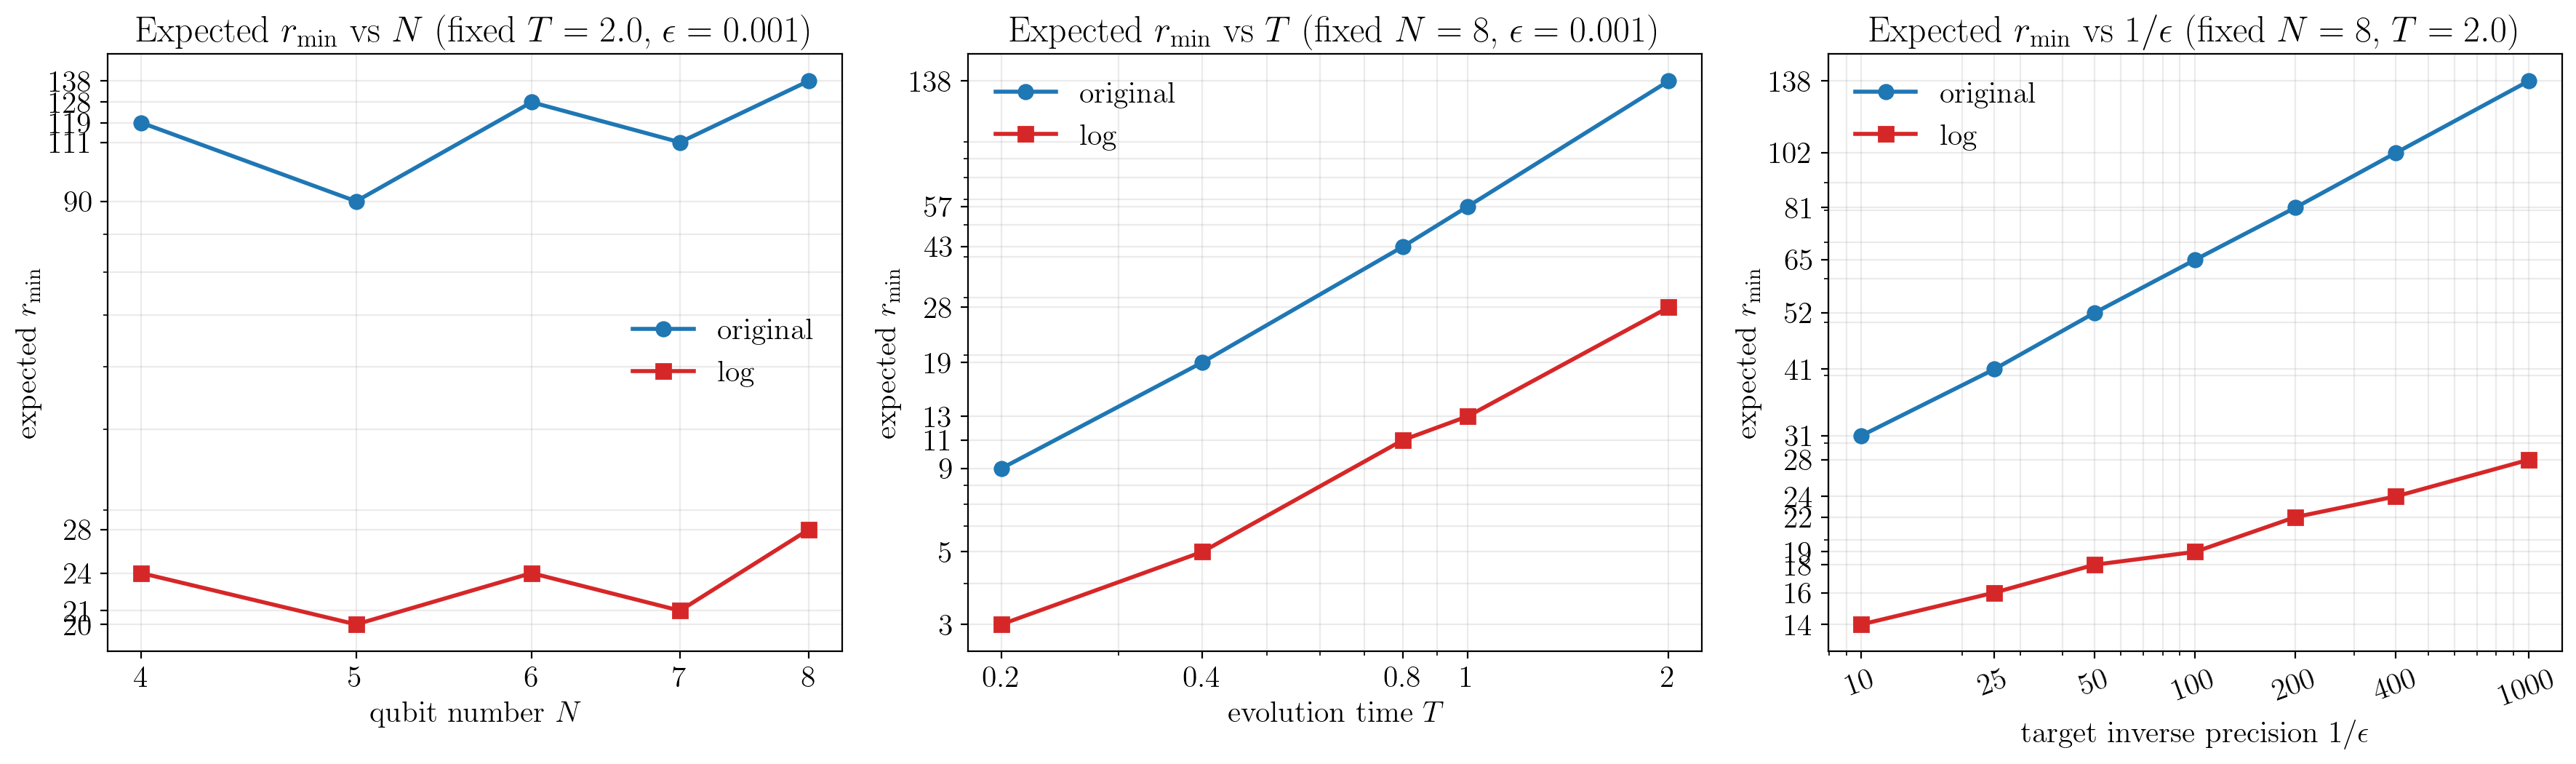

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
plot_expected_panel(
    axes[0],
    'N',
    r'qubit number $N$',
    rf'Expected $r_{{\min}}$ vs $N$ (fixed $T={BASELINE["T"]}$, $\epsilon={BASELINE["epsilon"]}$)',
)
plot_expected_panel(
    axes[1],
    'T',
    r'evolution time $T$',
    rf'Expected $r_{{\min}}$ vs $T$ (fixed $N={BASELINE["N"]}$, $\epsilon={BASELINE["epsilon"]}$)',
)
plot_expected_panel(
    axes[2],
    'inv_epsilon',
    r'target inverse precision $1/\epsilon$',
    rf'Expected $r_{{\min}}$ vs $1/\epsilon$ (fixed $N={BASELINE["N"]}$, $T={BASELINE["T"]}$)',
)
fig.tight_layout()
if SAVE_PDF:
    fig.savefig(FIG_DIR / f'scaling_{FIGURE_TAG}combined_expected.pdf', bbox_inches='tight')

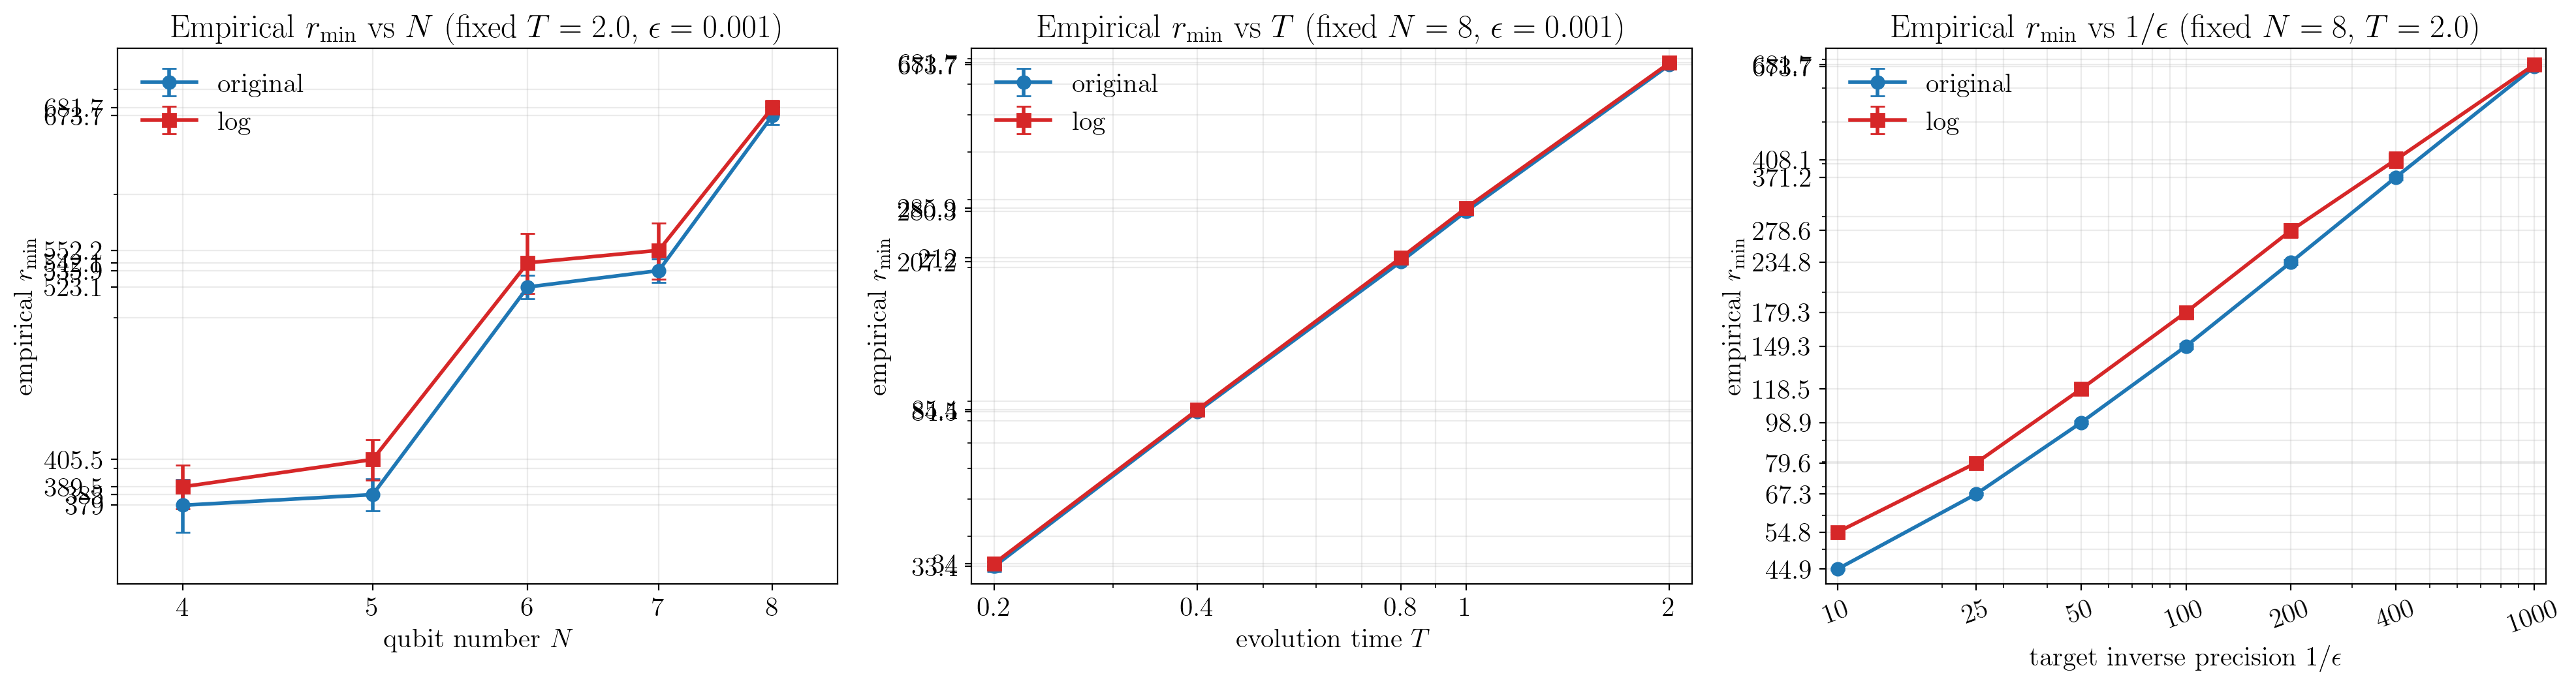

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
plot_empirical_panel(
    axes[0],
    'N',
    r'qubit number $N$',
    rf'Empirical $r_{{\min}}$ vs $N$ (fixed $T={BASELINE["T"]}$, $\epsilon={BASELINE["epsilon"]}$)',
)
plot_empirical_panel(
    axes[1],
    'T',
    r'evolution time $T$',
    rf'Empirical $r_{{\min}}$ vs $T$ (fixed $N={BASELINE["N"]}$, $\epsilon={BASELINE["epsilon"]}$)',
)
plot_empirical_panel(
    axes[2],
    'inv_epsilon',
    r'target inverse precision $1/\epsilon$',
    rf'Empirical $r_{{\min}}$ vs $1/\epsilon$ (fixed $N={BASELINE["N"]}$, $T={BASELINE["T"]}$)',
)
fig.tight_layout()
if SAVE_PDF:
    fig.savefig(FIG_DIR / f'scaling_{FIGURE_TAG}combined_empirical.pdf', bbox_inches='tight')